<a href="https://colab.research.google.com/github/TanishqKadyan18/data-cleaning-visualization/blob/main/Retail_Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd

# Load dataset and parse 'Date' column as datetime objects
df = pd.read_csv("sales.csv", parse_dates=["Date"])

# 1. Handle missing values (fill with mean of Sales column)
df['Sales'].fillna(df['Sales'].mean(), inplace=True)

# 2. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 3. Handle outliers in Profit using IQR method
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['Profit'] < (Q1 - 1.5 * IQR)) | (df['Profit'] > (Q3 + 1.5 * IQR)))]

# Show first 5 cleaned rows
df.head()

/tmp/ipykernel_1661/3918326670.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].mean(), inplace=True)


,Date,Store,Product,Sales,Profit
0,2024-01-01,A,Shoes,200,50
1,2024-01-02,B,Shirts,100,30
2,2024-01-03,C,Bags,300,-20
3,2024-01-04,A,Shoes,150,40
4,2024-01-05,B,Shirts,220,60


In [6]:
import pandas as pd

# Create mock retail dataset
data = {
    "Date": pd.date_range(start="2024-01-01", periods=30, freq="D"),
    "Store": ["A","B","C"] * 10,
    "Product": ["Shoes","Shirts","Bags"] * 10,
    "Sales": [200, 100, 300, 150, 220, 180, 250, 210, 200, 190] * 3,
    "Profit": [50, 30, -20, 40, 60, 25, 70, 55, -10, 35] * 3
}

df = pd.DataFrame(data)
df.to_csv("sales.csv", index=False)
print("✅ sales.csv created successfully!")
df.head()

✅ sales.csv created successfully!


,Date,Store,Product,Sales,Profit
0,2024-01-01,A,Shoes,200,50
1,2024-01-02,B,Shirts,100,30
2,2024-01-03,C,Bags,300,-20
3,2024-01-04,A,Shoes,150,40
4,2024-01-05,B,Shirts,220,60


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

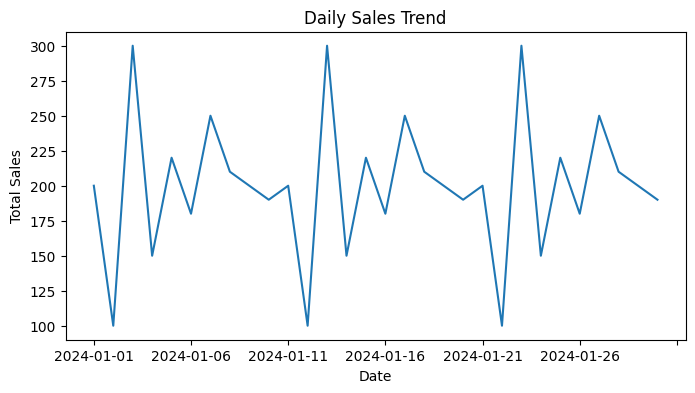

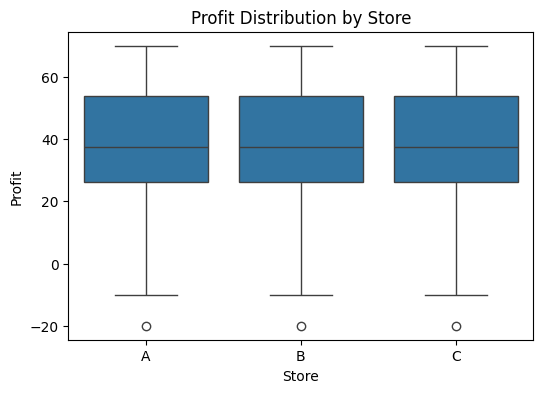

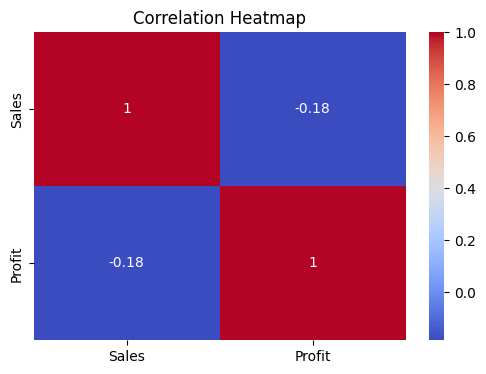

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daily Sales Trend
plt.figure(figsize=(8,4))
df.groupby("Date")["Sales"].sum().plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

# 2. Profit by Store
plt.figure(figsize=(6,4))
sns.boxplot(x="Store", y="Profit", data=df)
plt.title("Profit Distribution by Store")
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales', 'Profit']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


📈 Forecasted Sales:
 2024-01-31    228.726301
2024-02-01    197.960648
2024-02-02    213.096982
2024-02-03    201.170140
2024-02-04    213.349505
2024-02-05    203.145475
2024-02-06    211.857953
2024-02-07    203.730980
2024-02-08    210.707214
2024-02-09    205.160867
Freq: D, Name: predicted_mean, dtype: float64


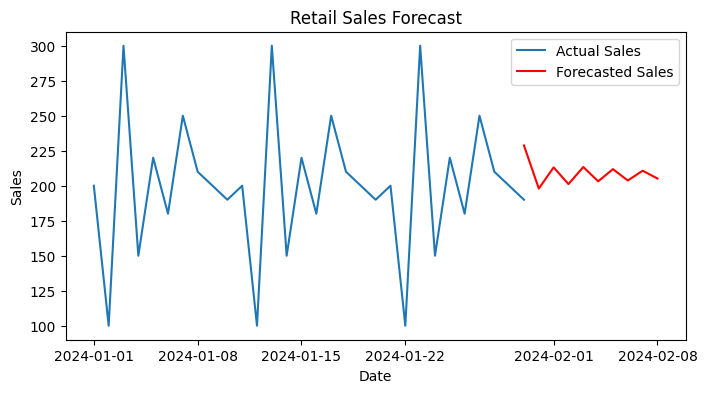

In [14]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Aggregate sales by date
sales_ts = df.groupby("Date")["Sales"].sum()

# Ensure the index of sales_ts is a DatetimeIndex
# This handles cases where 'Date' might not have been parsed as datetime previously
# or if the kernel state is inconsistent.
if not isinstance(sales_ts.index, pd.DatetimeIndex):
    sales_ts.index = pd.to_datetime(sales_ts.index)

# Fit ARIMA model (p=5, d=1, q=0 as a starting point)
model = ARIMA(sales_ts, order=(5,1,0))
model_fit = model.fit()

# Forecast next 10 days
forecast = model_fit.forecast(steps=10)

# Show forecasted values
print("📈 Forecasted Sales:\n", forecast)

# Plot actual vs forecast
plt.figure(figsize=(8,4))

# Convert dates to Matplotlib's internal numerical format for robust plotting
actual_dates_num = mdates.date2num(sales_ts.index.to_pydatetime())
forecast_dates = pd.date_range(sales_ts.index[-1], periods=10, freq="D")
forecast_dates_num = mdates.date2num(forecast_dates.to_pydatetime())

plt.plot(actual_dates_num, sales_ts.values, label="Actual Sales")
plt.plot(forecast_dates_num, forecast.values, label="Forecasted Sales", color="red")

# Apply date formatters to display dates correctly on the axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.title("Retail Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Retail Sales Forecasting Project

## Aim
To apply data science techniques on a retail dataset for cleaning, visualization, and forecasting future sales.

## Objective
- Perform end-to-end data analysis on retail sales data.  
- Handle missing values, duplicates, and outliers.  
- Visualize sales trends and profit distribution.  
- Build a forecasting model (ARIMA) to predict future sales.  

## Outcome
- Dataset cleaned and prepared for analysis.  
- Visual insights generated:
  - Daily sales trend identified.  
  - Profit distribution compared across stores.  
  - Correlation between sales and profit observed.  
- Forecasted sales for the next 10 days using ARIMA model.  

## Conclusion
Retail sales forecasting provides valuable insights for inventory planning and marketing strategies.  
This project demonstrates practical application of data cleaning, visualisation, and predictive modelling in a real-world retail context.
Insights